### $\chi^2$-statistic for model fitting

Tutorial taken from this Yale University Astro 330 scientific Python course on $\chi^2$ fitting [here](https://astro-330.github.io/Lab4/Lab4.html). The relevant papers are [Hogg (2010)](https://ui.adsabs.harvard.edu/abs/2010arXiv1008.4686H/abstract) and [Hogg (2018)](https://ui.adsabs.harvard.edu/abs/2018ApJS..236...11H/abstract), both saved in the <code>Background</code> folder of Zotero.

We have data $(x_i,y_i)$ with uncertainties $(\sigma_{x,i}, \sigma_{y,i})$, and wish to fit both a linear and quadratic model fit. We then calculate the $\chi^2$-statistic for the fit, as well as the reduced $\chi^2$ value, which is equal to $\chi^2/\nu$, with $\nu\equiv N-N_{\rm dof}$, where we have N data points, and each fit has $N_{\rm dof}$ parameters (e.g. for a linear fit with $y = ax + b$, $N_{\rm dof} = 2$). If the fit is good, the reduced $\chi^2$ value should be $\approx 1$.


np.polyfit():
gradient:      2.24 +/- 0.11 
y intercept:   34.0 +/- 18.2 

scipy.optimize.curve_fit():
gradient:      2.2399 +/- 0.1078
y intercept:   34.0477 +/- 18.2462 

 quadratic scipy.optimize.curve_fit(): y = q x^2 + m x + b
q:      0.0023 +/- 0.0000
m:      1.5961 +/- 0.3361
b:      72.8946 +/- 1514.1094 


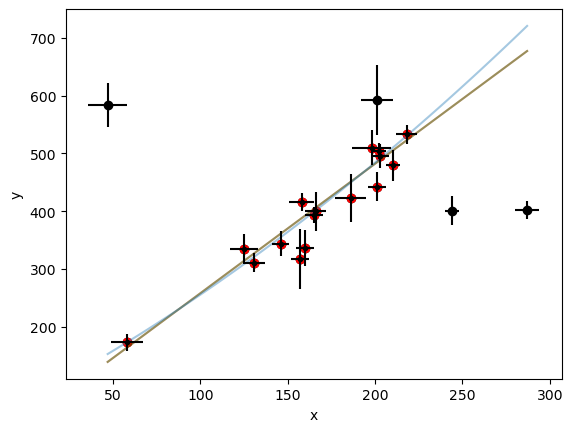

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# create Table 1 from Hogg (2010)

id = np.arange(1,21,1)
x = np.array([201, 244, 47, 287, 203, 58, 210,202,198,158,165,201,157,131,166,160,186,125,218,146])
y = np.array([592,401,583,402,495,173,479,504,510,416,393,442,317,311,400,337,423,334,533,344])
sigma_y = np.array([61,25,38,15,21,15,27,14,30,16,14,25,52,16,34,31,42,26,16,22])
sigma_x = np.array([9,4,11,7,5,9,4,4,11,7,5,5,5,6,6,5,9,8,6,5])
rho_xy = np.array([-0.84,0.31,0.64,-0.27,-0.33,0.67,-0.02,-0.05,-0.84,-0.69,0.3,-0.46,-0.03,0.5,0.73,-0.52,0.9,0.4,-0.78,-0.56])

mask = np.arange(4,20,1)

def model_func(x,a,b):
    return a*x + b

def quadratic_model(x,a,b,c):
    return a*x**2 + b*x + c
    
params, pcov = scipy.optimize.curve_fit(model_func,x[mask],y[mask],sigma=sigma_y[mask], absolute_sigma=True)
qparams, qpcov = scipy.optimize.curve_fit(quadratic_model, x[mask], y[mask], sigma=sigma_y[mask], absolute_sigma=True)

# polyfit method
p,pcov_2  = np.polyfit(x[mask],y[mask],1,w=1./sigma_y[mask],cov='unscaled')

perr = np.sqrt(np.diag(pcov_2))
print("\nnp.polyfit():")
print('gradient:      {:0.2f} +/- {:0.2f} '.format(p[0],perr[0]))
print('y intercept:   {:0.1f} +/- {:0.1f} '.format(p[1],perr[1]))

x_fit = np.linspace(np.min(x),np.max(x), 100)
y_fit = params[0]*x_fit + params[1]

y_fit_2 = p[0]*x_fit + p[1]

yq_fit = qparams[0]*x_fit**2 + qparams[1]*x_fit + qparams[2]

gradient = params[0]
y_intercept = params[1]
uncert_gradient = np.sqrt(np.diag(pcov)[0])
uncert_yint = np.sqrt(np.diag(pcov)[1])
print("\nscipy.optimize.curve_fit():")
print(f"gradient:      {gradient:0.4f} +/- {uncert_gradient:0.4f}")
print(f"y intercept:   {y_intercept:0.4f} +/- {uncert_yint:0.4f} ")

print("\n quadratic scipy.optimize.curve_fit(): y = q x^2 + m x + b")
print(f"q:      {qparams[0]:0.4f} +/- {np.diag(qpcov)[0]:0.4f}")
print(f"m:      {qparams[1]:0.4f} +/- {np.diag(qpcov)[1]:0.4f}")
print(f"b:      {qparams[2]:0.4f} +/- {np.diag(qpcov)[2]:0.4f} ")


fig,ax = plt.subplots()
ax.scatter(x,y,c='k')
ax.plot(x_fit,y_fit, '-', c = 'r', alpha =0.4)
ax.plot(x_fit, y_fit_2, c= 'g', alpha = 0.4)
ax.plot(x_fit, yq_fit, alpha = 0.4)
ax.errorbar(x,y, xerr=sigma_x,yerr=sigma_y, fmt='.',c='k')
ax.scatter(x[mask],y[mask],c='r')
ax.set(xlabel="x",ylabel='y')
plt.show()

In [15]:
# calculate the chi-squared value of the fits
def calc_chisq(xdata, ydata, yerr, func, params):
    f = func(xdata, *params)
    chisq = np.sum((ydata - f)**2/yerr**2)
    return chisq

chisq = calc_chisq(x[mask], y[mask], sigma_y[mask], model_func, params=[gradient, y_intercept])
n_dof = len(mask)

chisq_quad = calc_chisq(x[mask],y[mask], sigma_y[mask], quadratic_model, params=qparams)

print("\nlinear fit:")
print(f"chisq_min:         {chisq:0.4f}")
print(f"reduced chisq_min: {chisq/(n_dof - 2):0.4f}")
print("\nquadratic fit:")
print(f"chisq_min:         {chisq_quad:0.4f}")
print(f"reduced chisq_min: {chisq_quad/(n_dof - 3):0.4f}")



linear fit:
chisq_min:         18.6808
reduced chisq_min: 1.3343

quadratic fit:
chisq_min:         17.4032
reduced chisq_min: 1.3387


[19.68081795 20.98081795 24.85081795]


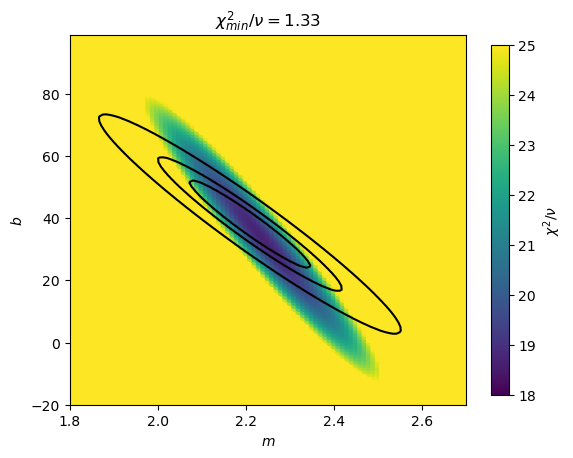

In [66]:
# plot the chi^2 statistic over a range of parameter values for the linear fit, to show the most likely values

m = np.arange(1.8,2.7,0.01)
b = np.arange(-20,100,1)
chi2_min = 1.e8
chi_sq_grid = np.zeros((len(m),len(b)))
m_arr, b_arr, chi_arr = [],[],[]

for i in range(len(m)):
    for j in range(len(b)):
        p = np.array([m[i],b[j]])
        chi_sq_grid[i,j] = calc_chisq(x[mask],y[mask],sigma_y[mask], model_func,p)
        m_arr.append(m[i])
        b_arr.append(b[j])
        chi_arr.append(chi_sq_grid[i,j])
        if chi_sq_grid[i,j] < chi2_min:
            chi2_min = chi_sq_grid[i,j]
            m_min    = m[i]
            b_min    = b[i]
extent = [np.min(m),np.max(m),np.min(b),np.max(b)]
fig,ax = plt.subplots()
# cb=ax.contourf(b,m,chi_sq_grid/(n_dof-2), levels=100)
# fig.colorbar(cb)
levels=[(chi2_min+1),(chi2_min+2.3),(chi2_min+6.17)]
print(np.array(levels))
im = ax.scatter(m_arr,b_arr,c=np.array(chi_arr),marker='o',s=18,vmin=18,vmax = 25.)
cb = plt.colorbar(im,ax=ax,shrink=0.945,label = '$\\chi^2/\\nu$')
ax.contour(chi_sq_grid,levels=levels,colors='k', extent=extent)
ax.set(title=f"$\\chi^2_{{min}}/\\nu = ${chi2_min/(n_dof-2):0.2f}", xlabel="$m$", ylabel="$b$")
plt.show()